# Linear Prediction Models

In [1]:
# Importing packages!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## What are Prediction Models?

Prediction models are a mathematical and computational method to determine future events. They are created by analyzing historical data. The overall distribution of data is analyzed and a model is created based on the distribution trends. 

## Why Create Prediction Models?

Models are relevant to the sciences, as they can help us map out the trends of biological processes, like organism growth, genetic change, and more. These models can predict future values based on possible biological inputs. They can help us simulate these biological processes and understand mechanisms behind them by examining different variables to create the model with.

## What is a Linear Prediction Model?

A linear prediction model is a type of prediction model that predicts values from inputs using a linear function. The linear prediction model is made with the **best-fit line**, which is the line that best follows the trend of the data.

A best-fit line is often constructed using the **Pearson correlation coefficient**. The Pearson correlation coefficient, denoted as $r$, measures the strength of the linear relationship between two variables. It is the slope of the best-fit line in standard units, where the mean is $0$ and the standard deviation is $1$.

## Creating a Linear Prediction Model

To work through the process of creating a linear prediction model, we will utilize the precipitation dataset. The dataset includes various observations, with each value in the   `precip` column representing the precipitation, while the corresponding value in the `growth` column represents the growth of an organism exposed to that precipitation level.

In [2]:
# Reads in the precipitation dataset
precip = pd.read_csv('precip.csv')
precip.head()

,precip,growth
0,2.176092,25.350882
1,2.280644,17.534213
2,1.703581,28.590446
3,1.061713,21.454899
4,1.718713,14.993775


### Constructing a Best-Fit Line

We can construct a best-fit line using standardardized units, with the Pearson correlation coefficient as the slope, or with the original units, using a calculated slope and y-intercept.

#### Best-Fit Lines with Standard Units

Let's first calculate a best-fit line using standard units. To standardize our data, we must subtract the mean from all the data, then divide it by the standard deviation. We'll create a function to make standardization easy.

In [20]:
# Converts an array of data to standard units
def convert_to_su(data_arr):
    # Subtracts the mean from the data
    mn_subtracted = data_arr - np.mean(data_arr)
    # Divides the subtracted data by the standard deviation
    su_data = mn_subtracted / np.std(data_arr)
    # Returns the standardized data
    return su_data

Let's standardize our data using this function.

In [4]:
# Standardizes the precipitation data
precip_su = convert_to_su(precip['precip'])
# Standardizes the growth data
growth_su = convert_to_su(precip['growth'])

Next, we'll calculate the Pearson correlation coefficient, which will serve as the slope for our best-fit line. This can either be done manually or using `np.corrcoef()`.

To calculate the Pearson correlation coefficient manually, we'll multiply the standardized data for the variables we're examining (in this case precipitation and growth), then take the mean of the multiplied values.

In [8]:
r = np.mean(precip_su * growth_su)
print(f'The manually-calculated Pearson correlation coefficient is {r}.')

The manually-calculated Pearson correlation coefficient is 0.19418647123114102.


Otherwise, we can calculate the Pearson correlation coefficient using `np.corrcoef()`. The function takes the data for each variable as the parameters, then calculates the coefficient. The function returns a matrix, so we'll have to extract the value at position `[0, 1]` to get the coefficient.

In [9]:
corr_matrix = np.corrcoef(precip['precip'], precip['growth'])
r = corr_matrix[0, 1]
print(f'The numpy-calculated Pearson correlation coefficient is {r}.')

The numpy-calculated Pearson correlation coefficient is 0.19418647123114094.


We can visualize our best-fit line with our standardized data. To do this, we can generate a series of x-values, then calculate the y-values for those x-values using the Pearson correlation coefficient as the slope.

Text(0.5, 1.0, 'Best-Fit Line in Standard Units')

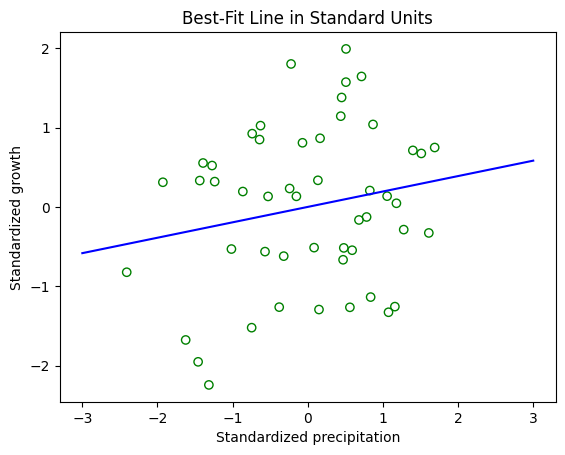

In [22]:
# Creates a figure for plotting
fig, ax1 = plt.subplots()

# Plots the standardized data
ax1.scatter(precip_su, growth_su, edgecolors = 'g', facecolors = 'none')

# Generates 20 x-values between -3 and 3
xvls=np.linspace(-3, 3, 20)
# Calculates the y-values using the Pearson correlation coefficient r
yvls = r * xvls
# Plots the best-fit line
ax1.plot(xvls, yvls, 'b')

# Labels the plot
ax1.set_xlabel('Standardized precipitation')
ax1.set_ylabel('Standardized growth')
ax1.set_title('Best-Fit Line in Standard Units')

#### Best-Fit Lines with Original Units

We can manually calculate the best-fit line by determining the slope and intercept. The equations for the slope and intercept are:

$$slope = r * (std(y)/std(x))$$
$$intercept = y - slope(x)$$

Let's calculate those using our calculated Pearson correlation coefficient $r$ and `numpy`.

In [15]:
# Calculates the slope of the best-fit line
slope = r * (np.std(precip['growth']) / np.std(precip['precip']))
# Calculates the intercept of the best-fit line
intercept = np.mean(precip['growth']) - slope * np.mean(precip['precip'])

Let's plot the best-fit line again, except with the original units.

Text(0.5, 1.0, 'Best-Fit Line in Original Units')

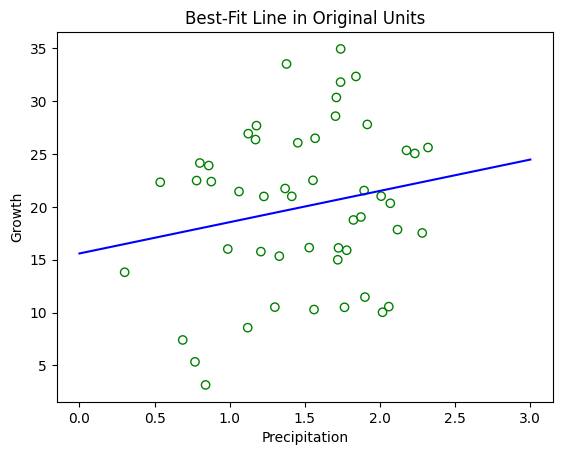

In [23]:
# Creates a figure for plotting
fig, ax2 = plt.subplots()

# Plots the original data
ax2.scatter(precip['precip'], precip['growth'], edgecolors = 'g', facecolors = 'none')

# Generates 20 x-values between 0 and 3
xvls = np.linspace(0, 3, 20)
# Calculates the y-values using our slope and intercept values
yvls = slope * xvls + intercept
# Plots the best-fit line
ax2.plot(xvls, yvls, 'b')

# Labels the plot
ax2.set_xlabel('Precipitation')
ax2.set_ylabel('Growth')
ax2.set_title('Best-Fit Line in Original Units')

### Predicting Values with the Linear Model

Since we have determined the slope and intercept for our linear prediction model, we can use that to predict the growth for a possible level of precipitation.

Let's see what the predicted growth is for a precipitation level of 3.

In [24]:
growth_prediction = slope * 3 + intercept
print(f'At a precipitation level of 3, the growth is predicted to be {growth_prediction}.')

At a precipitation level of 3, the growth is predicted to be 24.481837780469004.
